# CNeuroMod QA — MRIQC metrics

Raincloud distributions of per-run image-quality metrics (framewise displacement, tSNR) across subjects and datasets, read from `output_data/tables/`. Figures are written to `output_data/figures/qc_measures/`.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt  # noqa: F401
import numpy as np  # noqa: F401
import pandas as pd
import seaborn as sns

try:
    import ptitprince
    HAS_PTITPRINCE = True
except Exception:
    HAS_PTITPRINCE = False

# The shared house style lives next to the notebooks (nbconvert runs with
# notebooks/ as the cwd, so `analysis` is not importable here); the sys.path
# line makes the import work when the notebook is opened from the repo root too.
sys.path.insert(0, str(Path.cwd()))
import figure_style  # noqa: E402
from figure_style import GRID, HUE, INK, MUTED, style_axes  # noqa: E402,F401

# Paths are provided by `invoke run-notebooks` as environment variables.
# Figures go in output_data/figures/{FIG_NAME}/ (also the notebook's "already
# ran" sentinel); the metric tables live in output_data/tables/.
FIG_NAME = "qc_measures"
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data"))
FIG_DIR = OUTPUT_DIR / "figures" / FIG_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_tables(subdir):
    """Concatenate every non-empty TSV in output_data/<subdir>/."""
    frames = []
    for path in sorted((OUTPUT_DIR / subdir).glob("*.tsv")):
        try:
            frame = pd.read_csv(path, sep="\t")
        except (pd.errors.EmptyDataError, OSError):
            continue
        if not frame.empty:
            frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def panel(name, default, **kwargs):
    """A figure sized to the box the montage places `name` in (see figure_style)."""
    return plt.subplots(
        figsize=figure_style.panel_size(f"{FIG_NAME}/{name}", default),
        layout="constrained", **kwargs)


In [2]:
def raincloud(data, x, y, ax, color=None, ascending=True, order=None):
    """Half-violin + jittered strip in a single recessive hue (no boxplot).

    A full RainCloud stacks a half-violin, a boxplot, and a strip; we drop the
    box and compose the two remaining layers directly (ptitprince exposes
    `half_violinplot` and `stripplot`), with a seaborn fallback. The category is
    already named on the x-axis, so colour would carry no extra information; one
    hue keeps the ink recessive (dataviz skill).

    Mark sizes are set for the ~1-inch-tall boxes these panels are placed in on
    the montage: at page scale, larger dots merge into a solid blob.

    Categories are ordered along the x-axis by their median `y`: `ascending=True`
    (default) runs least-to-most left-to-right, the natural reading for FD-style
    "lower is better" metrics; pass `ascending=False` for tSNR, where higher is
    better, so the best sits on the left and the worst on the right. Pass an
    explicit `order` to override both — that is how the subject panels all share
    one order (see SUBJECT_ORDER)."""
    color = HUE if color is None else color
    data = data[[x, y]].dropna()
    if data.empty:
        ax.set_title(f"no data for {y}")
        return ax
    if order is None:
        order = (data.groupby(x)[y].median()
                     .sort_values(ascending=ascending).index.tolist())
    else:
        order = [cat for cat in order if cat in set(data[x])]
    n = max(data[x].nunique(), 1)
    if HAS_PTITPRINCE:
        try:
            ptitprince.half_violinplot(x=x, y=y, data=data, order=order,
                                       palette=[color] * n, bw=.15, width=.9,
                                       ax=ax, orient="v", inner=None, offset=-.05,
                                       linewidth=.4)
            ptitprince.stripplot(x=x, y=y, data=data, order=order,
                                 palette=[color] * n, ax=ax, orient="v", move=.2,
                                 size=.8, alpha=.65, edgecolor="white", linewidth=.1)
            if ax.get_legend():
                ax.get_legend().remove()
            return style_axes(ax)
        except Exception:
            ax.clear()
    sns.violinplot(data=data, x=x, y=y, ax=ax, order=order, color=color,
                   inner=None, cut=0, linewidth=.4)
    sns.stripplot(data=data, x=x, y=y, ax=ax, order=order, color=INK, size=.8,
                  alpha=.35)
    return style_axes(ax)

In [3]:
qc = load_tables("tables")
print(f"loaded {len(qc)} runs")
if qc.empty:
    print("No QC metrics found — run `invoke run-qc-measures` first "
          "(needs data access).")

# Every subject panel on the montage (b, c, d, h) shares one x-axis order:
# subjects sorted by their median mean-FD per run, calmest on the left. Letting
# each panel sort by its own metric put the same subject in a different column
# in every panel, so a reader could not carry a subject from one panel to the
# next; with a shared order the columns line up and the panels can be read
# against each other (does the highest-motion subject also have the worst tSNR?).
SUBJECT_ORDER = (qc.groupby("subject")["fd_mean"].median()
                   .sort_values().index.tolist()) if not qc.empty else []
print("subject order (median FD ascending):", SUBJECT_ORDER)
qc.head()

loaded 4537 runs
subject order (median FD ascending): [3, 4, 1, 5, 2, 6]


,dataset,subject,session,task,run,task_grouped,fd_mean,fd_num,fd_perc,tsnr,...,gsr_x,gsr_y,dvars_std,dvars_vstd,aor,aqi,gcor,size_t,fd_prop_gt02,fd_prop_gt05
0,floc,1,1.0,fLoc,1.0,fLoc,0.095655,4,2.580645,34.775093,...,-0.007330,0.092868,1.096233,1.014164,0.001235,0.005645,0.005919,155,0.025806,0.000000
1,floc,1,1.0,fLoc,2.0,fLoc,0.092470,3,1.935484,33.385800,...,-0.007088,0.094252,1.059803,0.989887,0.000598,0.006511,0.006913,155,0.019355,0.000000
2,floc,1,2.0,fLoc,1.0,fLoc,0.107802,8,5.194805,32.012708,...,-0.010132,0.095128,1.058638,0.992889,0.000651,0.007349,0.004041,154,0.051948,0.000000
3,floc,1,2.0,fLoc,2.0,fLoc,0.101230,12,7.792208,34.056397,...,-0.009027,0.094537,1.086857,1.020901,0.001314,0.005971,0.005213,154,0.077922,0.000000
4,floc,1,3.0,fLoc,1.0,fLoc,0.115155,11,7.142857,30.349011,...,-0.012415,0.096275,1.063736,1.007480,0.001540,0.009845,0.003522,154,0.071429,0.006494


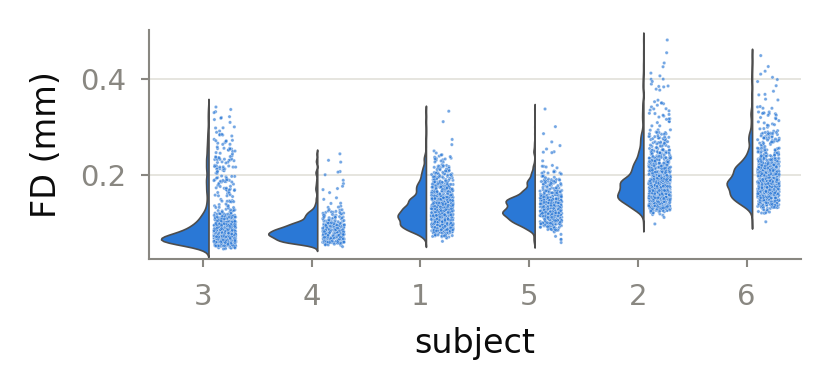

In [4]:
if not qc.empty:
    fig, ax = panel("fd_mean_by_subject.png", (12, 7))
    raincloud(qc, "subject", "fd_mean", ax, order=SUBJECT_ORDER)
    ax.set_xlabel("subject")
    ax.set_ylabel("FD (mm)")
    fig.savefig(FIG_DIR / "fd_mean_by_subject.png", dpi=figure_style.PAGE_DPI)

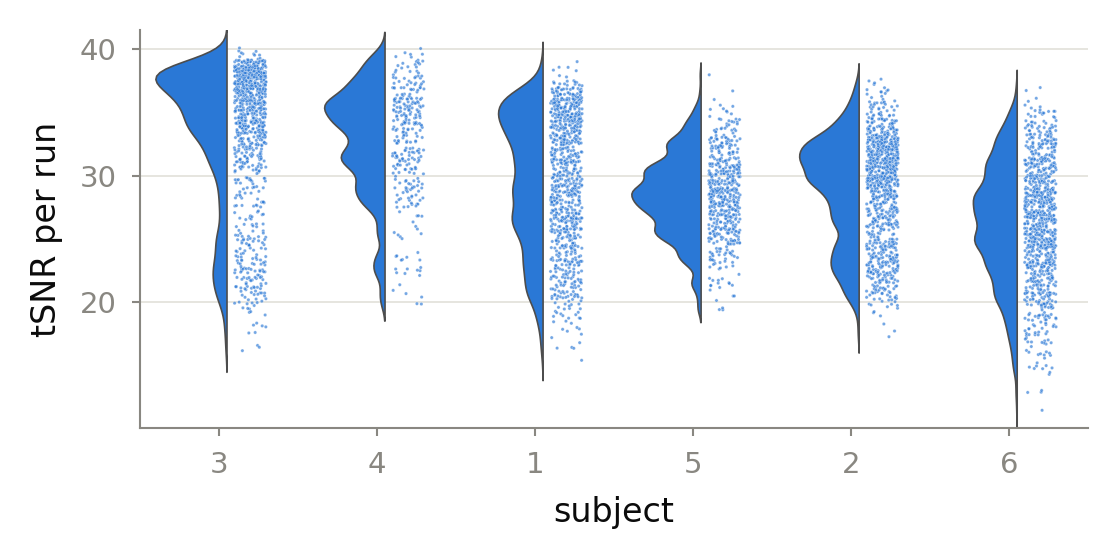

In [5]:
if not qc.empty:
    fig, ax = panel("tsnr_by_subject.png", (12, 7))
    raincloud(qc, "subject", "tsnr", ax, order=SUBJECT_ORDER)
    ax.set_xlabel("subject")
    ax.set_ylabel("tSNR per run")
    fig.savefig(FIG_DIR / "tsnr_by_subject.png", dpi=figure_style.PAGE_DPI)

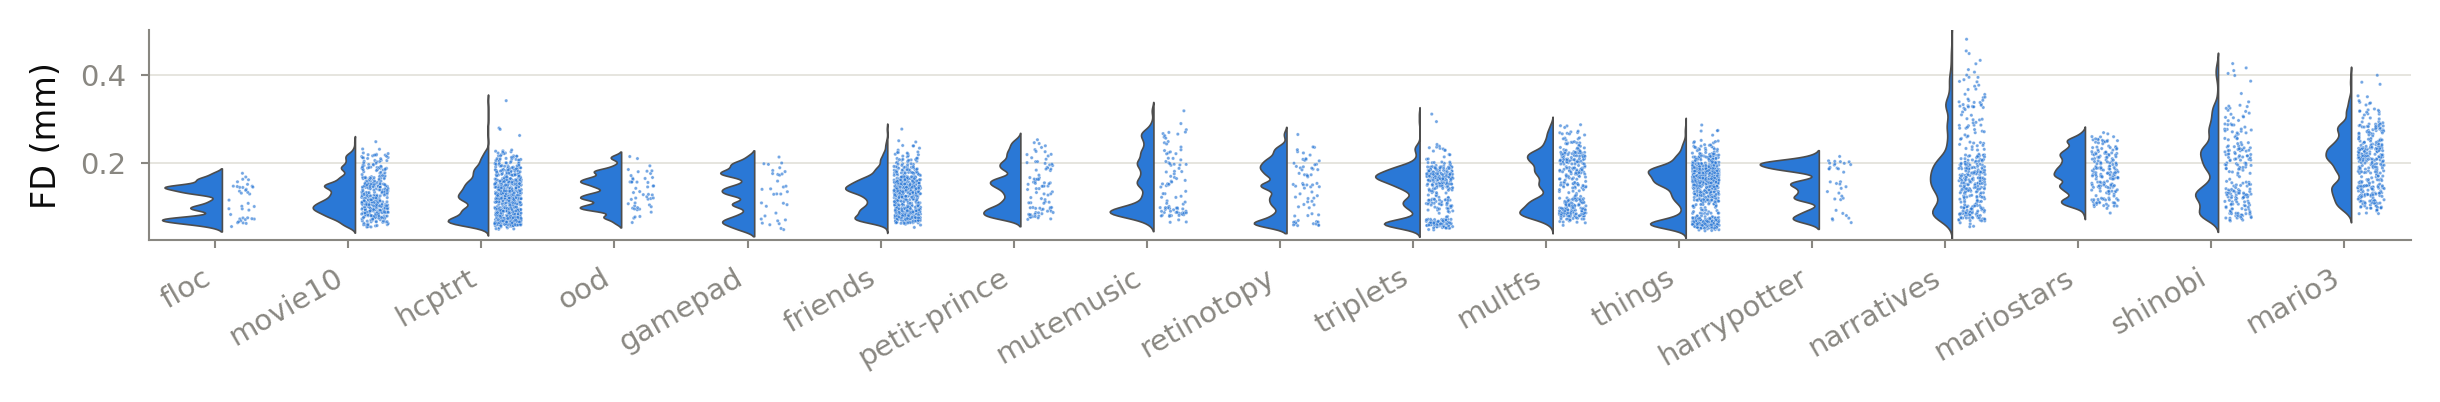

In [6]:
if not qc.empty and qc["dataset"].notna().any():
    # Panel a on the montage: a wide, ~1.2-inch-tall strip. At 6 pt the 17
    # dataset names are still too wide to sit flat side by side across 8
    # inches, so they keep a shallow 30-degree tilt (45 would cost more of
    # the 1.2 inches of height than the panel can spare).
    fig, ax = panel("fd_mean_by_dataset.png", (14, 7))
    raincloud(qc, "dataset", "fd_mean", ax)
    ax.tick_params("x", labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.set_xlabel("")
    ax.set_ylabel("FD (mm)")
    fig.savefig(FIG_DIR / "fd_mean_by_dataset.png", dpi=figure_style.PAGE_DPI)

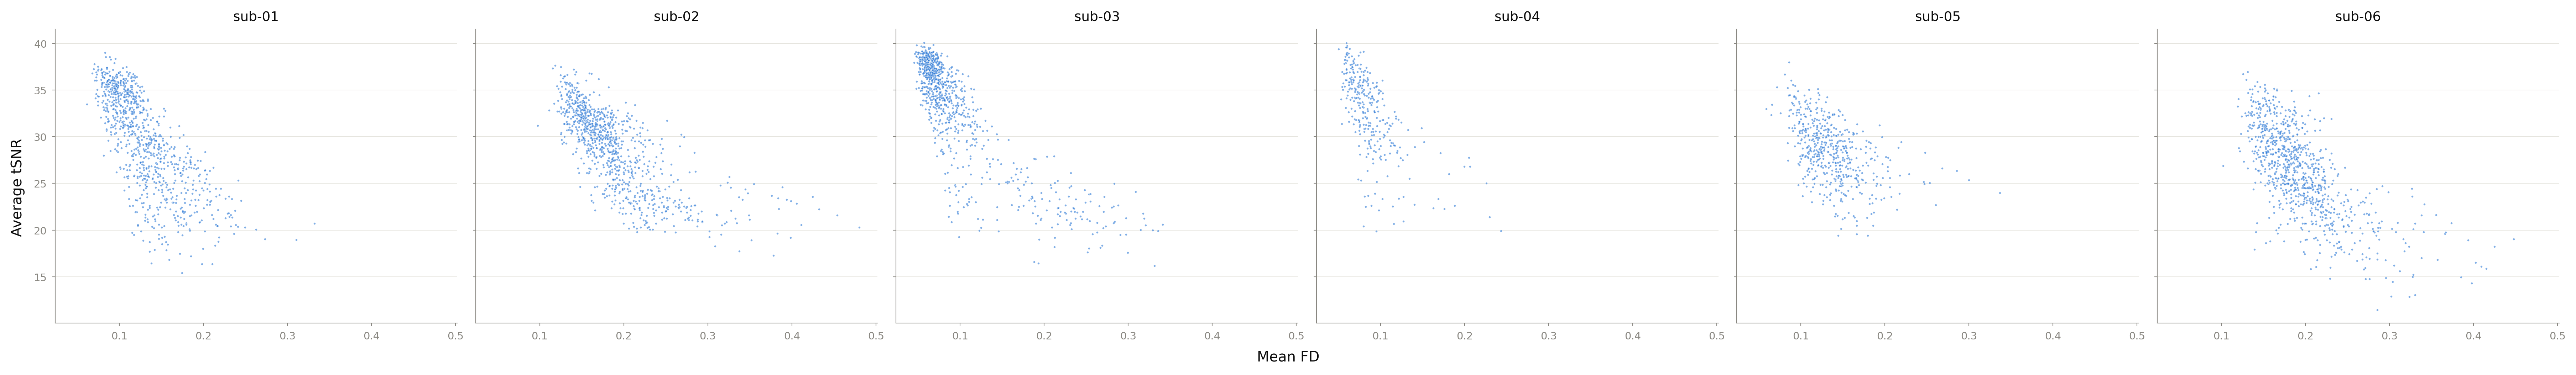

In [7]:
if not qc.empty and qc[["fd_mean", "tsnr"]].dropna().shape[0] > 0:
    # One panel per subject (small multiples), all on a single row: subject
    # identity is carried by facet position, not colour. Six categorical hues on
    # a single scatter fail the dataviz colour-blind separation check (validated:
    # green vs orange ΔE 3.2); faceting sidesteps it while keeping every subject
    # legible.
    subjects = sorted(qc["subject"].dropna().unique())
    ncols = len(subjects)
    fig, axes = panel("fd_vs_tsnr.png", (4 * ncols, 3.4), ncols=ncols,
                      squeeze=False, sharex=True, sharey=True)
    flat_axes = axes.flatten()
    for ax, subject in zip(flat_axes, subjects):
        sub = qc[qc["subject"] == subject]
        ax.scatter(sub["fd_mean"], sub["tsnr"], s=2, color=HUE, alpha=.6,
                   edgecolor="white", linewidth=.2)
        ax.set_title(f"sub-{int(subject):02d}")
        style_axes(ax)
    fig.supxlabel("Mean FD")
    fig.supylabel("Average tSNR")
    fig.savefig(FIG_DIR / "fd_vs_tsnr.png", dpi=figure_style.PAGE_DPI)


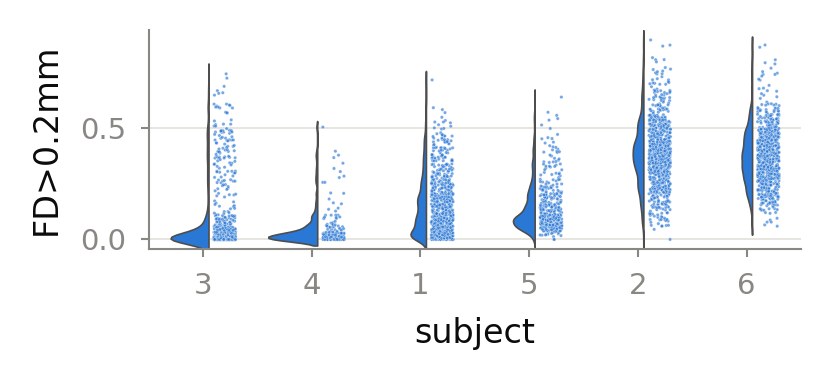

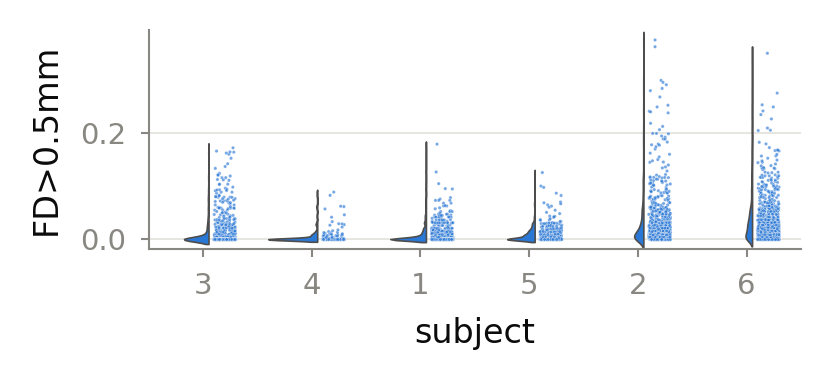

In [8]:
for col, thr in [("fd_prop_gt02", 0.2), ("fd_prop_gt05", 0.5)]:
    if not qc.empty and col in qc and qc[col].notna().any():
        fig, ax = panel(f"{col}_by_subject.png", (12, 7))
        raincloud(qc, "subject", col, ax, order=SUBJECT_ORDER)
        ax.set_xlabel("subject")
        # Terse on purpose: the placed box is ~1.15 in tall, and a longer
        # label is taller than the panel itself, so matplotlib clips it.
        ax.set_ylabel(f"FD>{thr}mm")
        fig.savefig(FIG_DIR / f"{col}_by_subject.png", dpi=figure_style.PAGE_DPI)